In [255]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [256]:
df = pd.read_csv("/Users/genadit/Downloads/OptionChain.csv")


df.columns = df.columns.str.strip()

In [257]:
def bsm_greeks(row, vol_col="Vol (Hist)"):
    S  = row["Spot"]
    K  = row["Strike"]
    r  = row["RFR"]
    sigma = row[vol_col]
    T  = row["T (Years)"]
    opt= row["Type"].lower()

    if T <= 0 or sigma <= 0:
        return {}

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    n_d1  = norm.pdf(d1)
    N_d1  = norm.cdf(d1)
    N_d2  = norm.cdf(d2)
    Nm_d1 = norm.cdf(-d1)
    Nm_d2 = norm.cdf(-d2)

    if opt == "call":
        delta = N_d1
        theta = (-(S * n_d1 * sigma) / (2 * np.sqrt(T))
                 - r * K * np.exp(-r * T) * N_d2) / 365
        rho   = K * T * np.exp(-r * T) * N_d2 / 100
    else:
        delta = N_d1 - 1
        theta = (-(S * n_d1 * sigma) / (2 * np.sqrt(T))
                 + r * K * np.exp(-r * T) * Nm_d2) / 365
        rho   = -K * T * np.exp(-r * T) * Nm_d2 / 100

    gamma = n_d1 / (S * sigma * np.sqrt(T))
    vega  = S * n_d1 * np.sqrt(T) / 100

    vanna  = -n_d1 * d2 / sigma
    vomma  = vega * d1 * d2 / sigma

    charm = (-n_d1 * (2 * r * T - d2 * sigma * np.sqrt(T))
             / (2 * T * sigma * np.sqrt(T))) / 365

    veta = (S * n_d1 * np.sqrt(T)
            * (r * d1 / (sigma * np.sqrt(T))
               - (1 + d1 * d2) / (2 * T))) / (100 * 365)

    return dict(
        d1=d1, d2=d2,
        Delta=delta, Gamma=gamma, Vega=vega, Theta=theta, Rho=rho,
        Vanna=vanna, Vomma=vomma, Charm=charm, Veta=veta,
    )

In [258]:
greeks_rows = []
for _, row in df.iterrows():
    g = bsm_greeks(row, vol_col="Vol (Hist)")
    g.update({
        "Stock": row["Stock"],
        "Expiry": row["Expiry"],
        "Type": row["Type"],
        "Moneyness": row["Moneyness"],
        "Strike": row["Strike"],
        "Spot": row["Spot"],
        "Vol": row["Vol (Hist)"],
        "Market Price": row["Market Price"],
    })
    greeks_rows.append(g)

gdf = pd.DataFrame(greeks_rows)

cols_order = ["Stock","Expiry","Type","Moneyness","Strike","Spot","Vol",
              "Delta","Gamma","Vega","Theta","Rho",
              "Vanna","Vomma","Charm","Veta","Market Price"]

gdf = gdf[cols_order]

In [259]:
pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)
from IPython.display import display

display(gdf)

print("\n" + "="*120)
print("FULL GREEKS TABLE (Historical Volatility)")
print("="*120)
print(gdf.to_string(index=False))
print("="*120)

,Stock,Expiry,Type,Moneyness,Strike,Spot,Vol,Delta,Gamma,Vega,Theta,Rho,Vanna,Vomma,Charm,Veta,Market Price
0,HDFCBANK,28-Apr-2026,Call,ATM (±2%),810,810.000000,0.173032,0.535980,0.015021,0.607361,-0.482745,0.150513,-0.132392,0.018277,-0.001380,-0.023170,19.000000
1,HDFCBANK,28-Apr-2026,Call,OTM (5-10%),875,810.000000,0.173032,0.011498,0.001138,0.046009,-0.032331,0.003280,0.401137,1.394096,-0.002841,-0.011643,3.000000
2,HDFCBANK,28-Apr-2026,Put,ATM (±2%),810,810.000000,0.173032,-0.464020,0.015021,0.607361,-0.332575,-0.137281,-0.132392,0.018277,-0.001380,-0.023170,19.000000
3,HDFCBANK,28-Apr-2026,Put,OTM (5-10%),750,810.000000,0.173032,-0.007200,0.000755,0.030540,-0.019229,-0.002100,-0.278774,1.042828,0.001742,-0.007689,3.700000
4,HDFCBANK,26-May-2026,Call,ATM (±2%),810,810.000000,0.173032,0.563711,0.008384,1.069191,-0.306402,0.488300,-0.233061,0.101477,-0.000770,-0.012703,31.700000
5,HDFCBANK,26-May-2026,Call,OTM (5-10%),875,810.000000,0.173032,0.120872,0.004280,0.545837,-0.132867,0.106910,1.427669,4.537138,-0.003657,-0.018278,10.050000
6,HDFCBANK,26-May-2026,Put,ATM (±2%),810,810.000000,0.173032,-0.436289,0.008384,1.069191,-0.157011,-0.414659,-0.233061,0.101477,-0.000770,-0.012703,29.600000
7,HDFCBANK,26-May-2026,Put,OTM (5-10%),745,810.000000,0.173032,-0.054488,0.002351,0.299770,-0.054847,-0.050822,-0.985845,4.289654,0.001726,-0.011168,8.600000
8,NESTLEIND,28-Apr-2026,Call,ATM (±2%),1260,1256.900000,0.160031,0.505398,0.010509,0.946223,-0.697657,0.220862,0.041554,-0.001334,-0.002710,-0.036307,26.200000
9,NESTLEIND,28-Apr-2026,Call,OTM (5-10%),1350,1256.900000,0.160031,0.011577,0.000798,0.071814,-0.046879,0.005129,0.435330,2.344980,-0.002866,-0.018199,2.750000



FULL GREEKS TABLE (Historical Volatility)
    Stock      Expiry Type   Moneyness  Strike        Spot      Vol     Delta    Gamma     Vega     Theta       Rho     Vanna     Vomma     Charm      Veta  Market Price
 HDFCBANK 28-Apr-2026 Call   ATM (±2%)     810  810.000000 0.173032  0.535980 0.015021 0.607361 -0.482745  0.150513 -0.132392  0.018277 -0.001380 -0.023170     19.000000
 HDFCBANK 28-Apr-2026 Call OTM (5-10%)     875  810.000000 0.173032  0.011498 0.001138 0.046009 -0.032331  0.003280  0.401137  1.394096 -0.002841 -0.011643      3.000000
 HDFCBANK 28-Apr-2026  Put   ATM (±2%)     810  810.000000 0.173032 -0.464020 0.015021 0.607361 -0.332575 -0.137281 -0.132392  0.018277 -0.001380 -0.023170     19.000000
 HDFCBANK 28-Apr-2026  Put OTM (5-10%)     750  810.000000 0.173032 -0.007200 0.000755 0.030540 -0.019229 -0.002100 -0.278774  1.042828  0.001742 -0.007689      3.700000
 HDFCBANK 26-May-2026 Call   ATM (±2%)     810  810.000000 0.173032  0.563711 0.008384 1.069191 -0.306402  

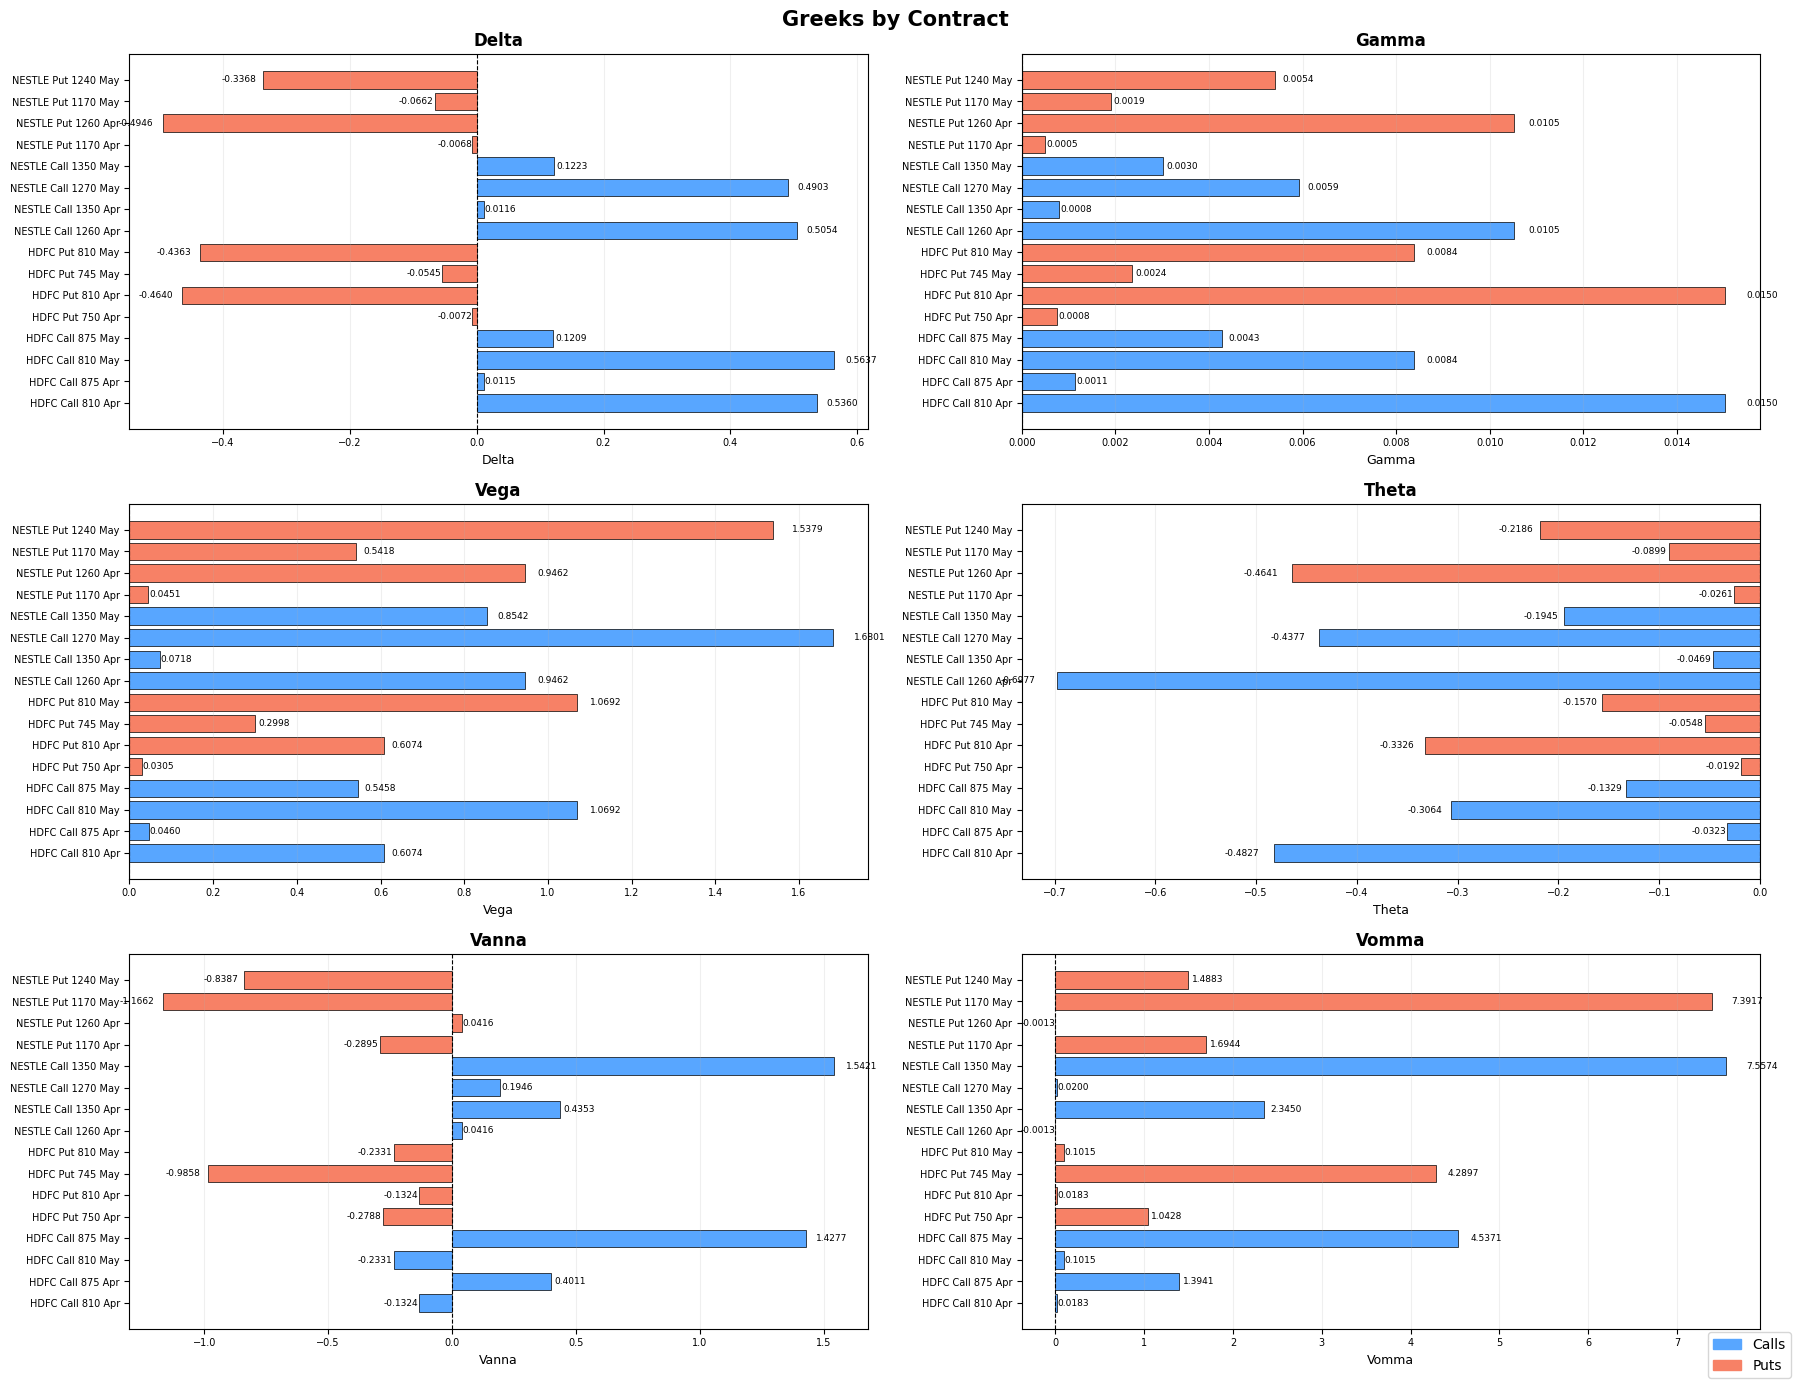

In [263]:
gdf = gdf.dropna()

gdf["Expiry_dt"] = pd.to_datetime(gdf["Expiry"])

gdf = gdf.sort_values(by=["Stock", "Type", "Expiry_dt", "Strike"])


gdf["Label"] = (
    gdf["Stock"].str.replace("BANK", "", regex=False).str.replace("IND", "", regex=False) +
    " " +
    gdf["Type"] +
    " " +
    gdf["Strike"].astype(int).astype(str) +
    " " +
    gdf["Expiry_dt"].dt.strftime("%b")
)


# WHITE BACKGROUND
plt.style.use('default')

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.patch.set_facecolor('white')
fig.suptitle("Greeks by Contract", fontsize=15, fontweight="bold", color="black")

plot_greeks = [
    ("Delta",  CALL_COLOR),
    ("Gamma",  "#d62728"),
    ("Vega",   NEST_COL),
    ("Theta",  PUT_COLOR),
    ("Vanna",  "#1f77b4"),
    ("Vomma",  HDFC_COL),
]

for ax, (greek, color) in zip(axes.flat, plot_greeks):

    # CALL vs PUT COLOR LOGIC (preserved intent)
    colors = [
        CALL_COLOR if t == "Call" else PUT_COLOR
        for t in gdf["Type"]
    ]

    bars = ax.barh(
        gdf["Label"],
        gdf[greek],
        color=colors,
        edgecolor="black",
        linewidth=0.5
    )

    ax.set_facecolor("white")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(greek, fontsize=12, fontweight="bold", color="black")
    ax.tick_params(labelsize=7, colors="black")
    ax.set_xlabel(greek, fontsize=9, color="black")
    ax.grid(axis="x", alpha=0.2)

    for bar, val in zip(bars, gdf[greek]):
        ax.text(
            val + abs(val)*0.03 if val >= 0 else val - abs(val)*0.03,
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f}",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=6.5,
            color="black"
        )


from matplotlib.patches import Patch
handles = [
    Patch(color=CALL_COLOR, label="Calls"),
    Patch(color=PUT_COLOR, label="Puts")
]

fig.legend(handles=handles, loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()
plt.close()

In [265]:
gdf["Contract"] = (
    gdf["Stock"].astype(str) + "-" +
    gdf["Type"].astype(str) + "-" +
    gdf["Expiry"].astype(str)
)

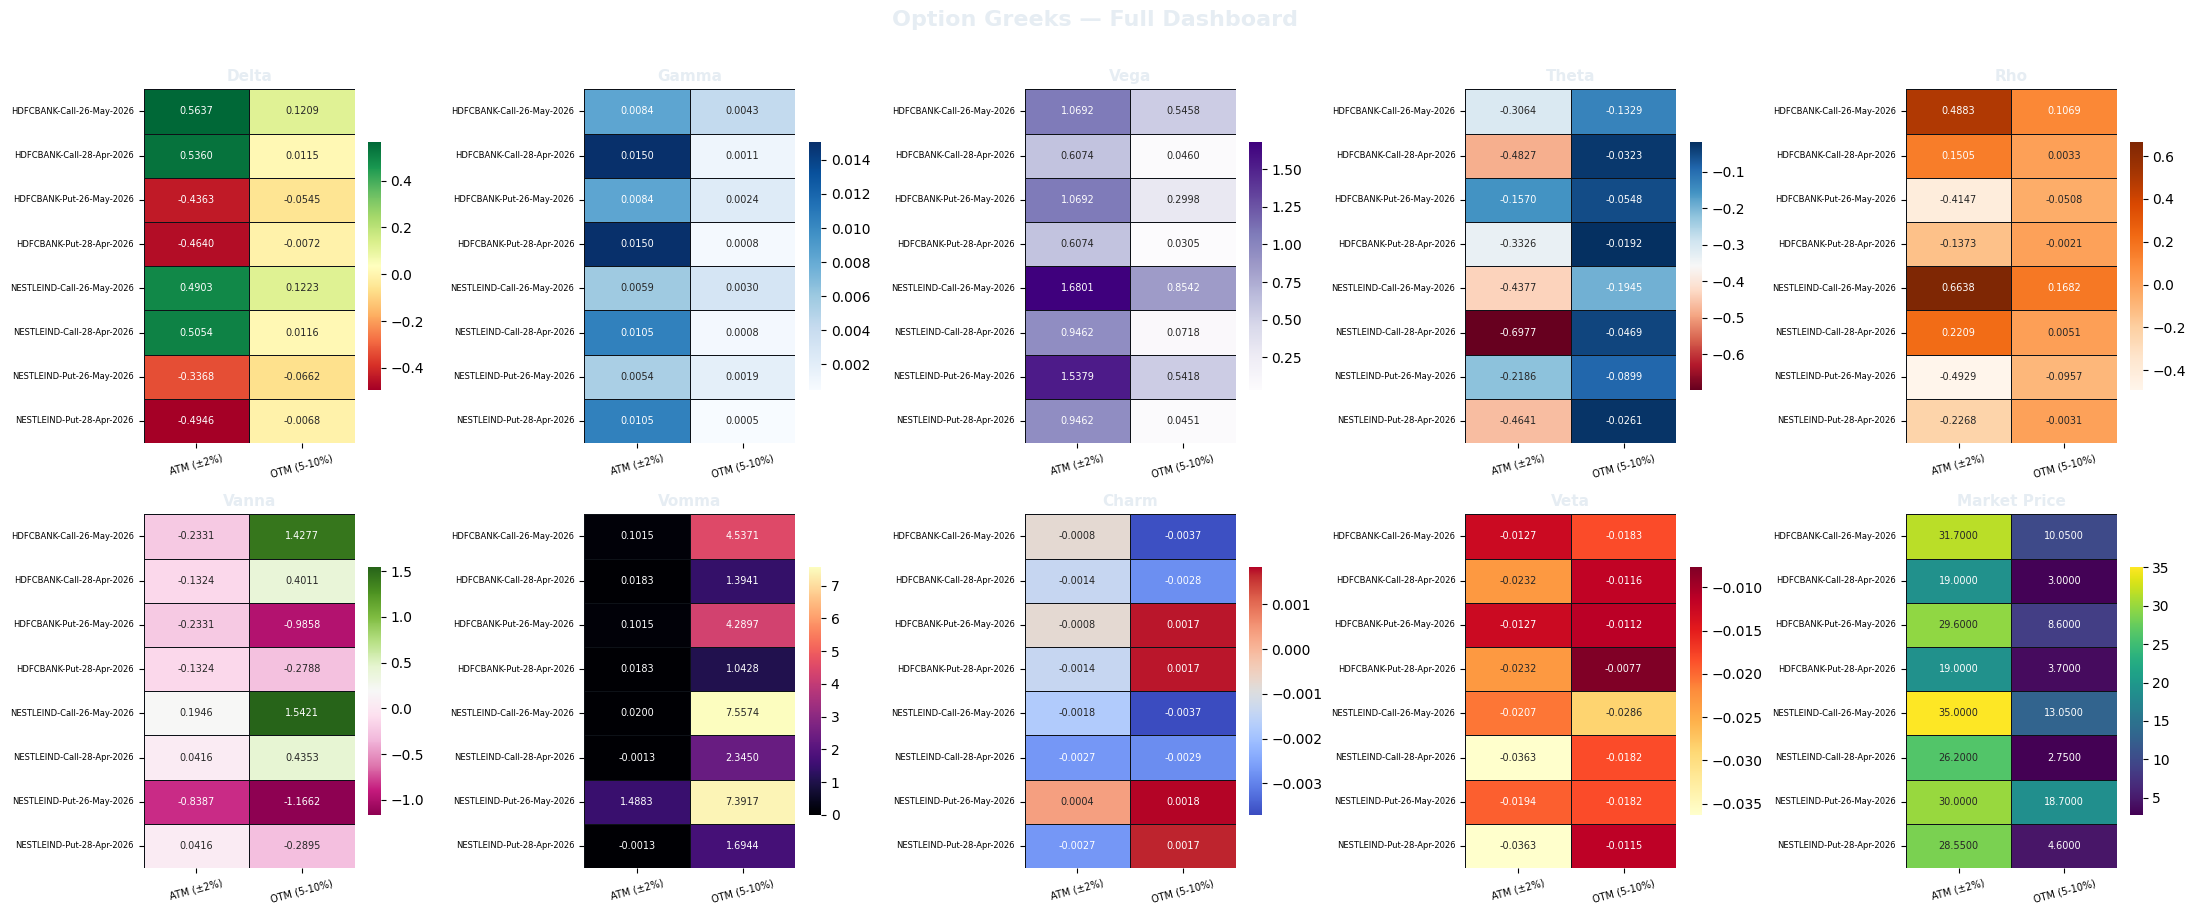

In [266]:
#Greeks heatmap grid 
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle("Option Greeks — Full Dashboard",
             fontsize=16, fontweight="bold",
             color="#e6edf3", y=1.01)

greek_list = ["Delta","Gamma","Vega","Theta","Rho",
              "Vanna","Vomma","Charm","Veta","Market Price"]

cmaps = ["RdYlGn","Blues","Purples","RdBu","Oranges",
         "PiYG","magma","coolwarm","YlOrRd","viridis"]

# ensure clean data
gdf = gdf.dropna()
gdf["Moneyness"] = gdf["Moneyness"].str.strip()

for ax, g, cm in zip(axes.flat, greek_list, cmaps):

    pivot = gdf.pivot_table(
        index="Contract",        
        columns="Moneyness",
        values=g,
        aggfunc="mean"
    )

    sns.heatmap(
        pivot,
        ax=ax,
        cmap=cm,
        annot=True,
        fmt=".4f",
        linewidths=0.5,
        linecolor="#0d1117",
        annot_kws={"size": 7},
        cbar_kws={"shrink": 0.7}
    )

    ax.set_title(g, fontsize=11, fontweight="bold", color="#e6edf3")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='x', rotation=15, labelsize=7)
    ax.tick_params(axis='y', labelsize=6)

plt.tight_layout()

plt.show()   
plt.close()


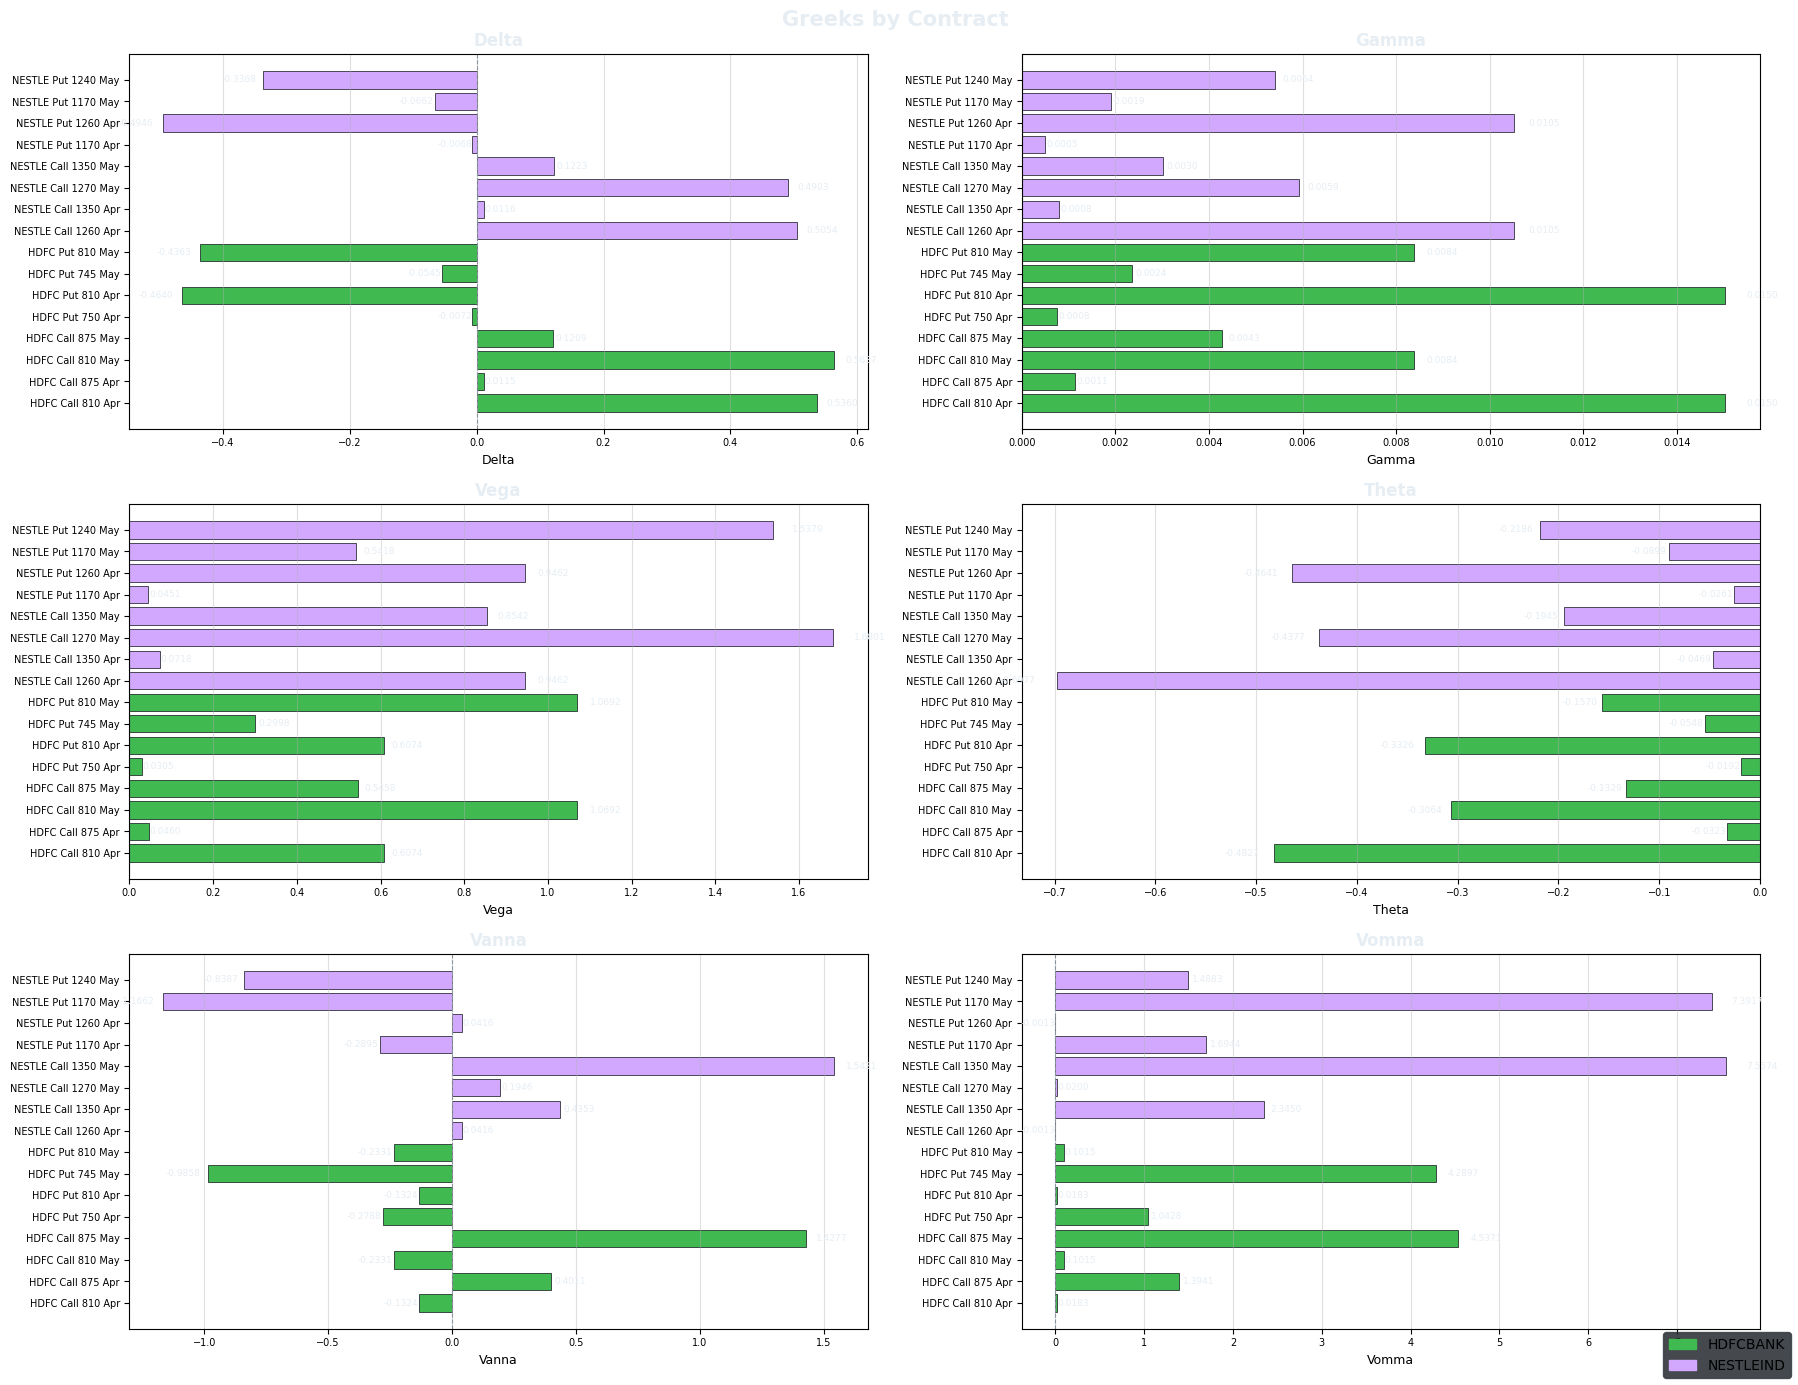


HDFCBANK PORTFOLIO
                     Leg  Qty  Type  Strike     Price     Delta    Gamma     Vega  Value Contrib  Delta Contrib
0  Short 2× Apr ATM Call   -2  Call     810 11.550000  0.536000 0.015000 0.607400     -23.090000      -1.072000
1   Long 1× Apr OTM Call    1  Call     875  0.100000  0.011500 0.001100 0.046000       0.100000       0.011500
2   Short 2× Apr ATM Put   -2   Put     810  9.590000 -0.464000 0.015000 0.607400     -19.180000       0.928000
3    Long 1× Apr OTM Put    1   Put     750  0.060000 -0.007200 0.000800 0.030500       0.060000      -0.007200
4   Long 1× May ATM Call    1  Call     810 21.900000  0.563700 0.008400 1.069200      21.900000       0.563700
5   Short 1× May OTM Put   -1   Put     745  1.110000 -0.054500 0.002400 0.299800      -1.110000       0.054500

Summary:
Value : -21.31
Delta : 0.4786
Gamma : -0.0522
Vega  : -1.5835



NESTLE PORTFOLIO
                  Leg  Qty  Type  Strike     Price    Delta    Gamma     Vega  Value Contrib  Delta Contrib
0      Long Call 1170    1  Call    1170 89.810000 0.993200 0.000500 0.045100      89.810000       0.993200
1  Short 2× Call 1260   -2  Call    1260 15.110000 0.505400 0.010500 0.946200     -30.230000      -1.010800
2      Long Call 1350    1  Call    1350  0.150000 0.011600 0.000800 0.071800       0.150000       0.011600

Summary:
Value : 59.73
Delta : -0.0060
Gamma : -0.0197
Vega  : -1.7755



DELTA HEDGE
HDFC  → SELL 0.48 shares | Cost -387.65
NESTLE→ BUY 0.01 shares | Cost 7.57



POST-HEDGE GREEKS
                          Delta      Gamma       Vega
----------------------------------------------------
HDFC (post-hedge)      0.000000  -0.052158  -1.583473
NESTLE (post-hedge)    0.000000  -0.019719  -1.775539


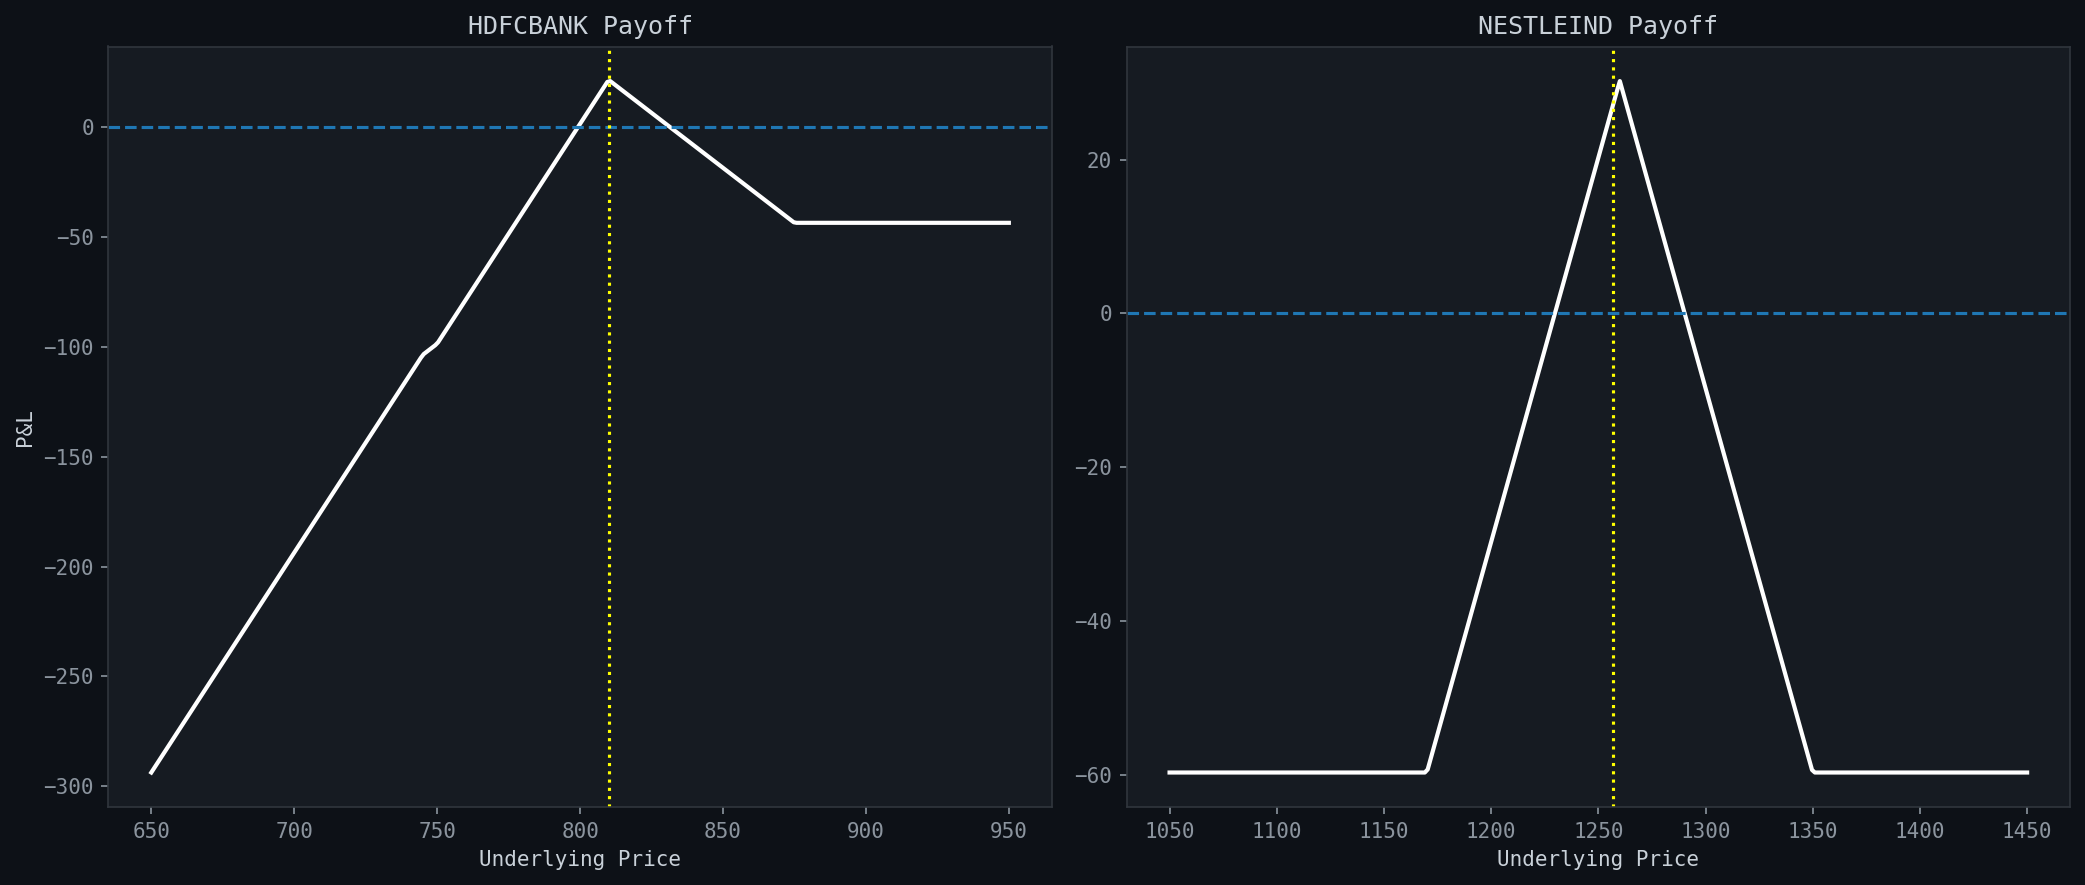

In [244]:
from scipy.stats import norm
import numpy as np
import pandas as pd


In [245]:
def bsm_price(S, K, r, sigma, T, opt_type):
    if T <= 0 or sigma <= 0:
        return max(S-K, 0) if opt_type == 'Call' else max(K-S, 0)

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if opt_type == 'Call':
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

In [246]:
def port_value(legs, S, r, vol_mult=1.0):
    total = 0.0

    for qty, _, opt_type, K, T, sigma, _ in legs:
        price = bsm_price(S, K, r, sigma * vol_mult, T, opt_type)
        total += qty * price

    return total



In [247]:
def portfolio_delta(legs, S, r):
    total_delta = 0.0

    for qty, _, opt_type, K, T, sigma, _ in legs:
        if T <= 0 or sigma <= 0:
            continue

        d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

        if opt_type == 'Call':
            delta = norm.cdf(d1)
        else:
            delta = norm.cdf(d1) - 1

        total_delta += qty * delta

    return total_delta



In [248]:
base_hdfc   = port_value(HDFC_PORT,   S_hdfc,   r_hdfc)
base_nestle = port_value(NESTLE_PORT, S_nestle, r_nestle)


hdfc_shares = -portfolio_delta(HDFC_PORT,   S_hdfc,   r_hdfc)
ne_shares   = -portfolio_delta(NESTLE_PORT, S_nestle, r_nestle)

In [249]:
price_shocks = [-0.02, -0.01, 0.00, 0.01, 0.02]
vol_mults    = [0.80,  1.00,  1.20]

price_labels = ['-2%', '-1%', '0%', '+1%', '+2%']
vol_labels   = ['-20% Vol', 'Base Vol', '+20% Vol']


In [250]:
def build_pnl_table(legs, S0, r, base_val, hedge_shares, name):
    rows = []

    for vm, vl in zip(vol_mults, vol_labels):
        row = {'Portfolio': name, 'Vol Scenario': vl}

        for ps, pl in zip(price_shocks, price_labels):
            S_new = S0 * (1 + ps)

            new_val = port_value(legs, S_new, r, vm)

            pnl_unhedged = new_val - base_val
            pnl_hedged   = pnl_unhedged + hedge_shares * (S_new - S0)

            row[f'{pl} Unhedged'] = round(pnl_unhedged, 2)
            row[f'{pl} Hedged']   = round(pnl_hedged, 2)

        rows.append(row)

    return pd.DataFrame(rows)


In [251]:
hdfc_pnl   = build_pnl_table(HDFC_PORT,   S_hdfc,   r_hdfc,   base_hdfc,   hdfc_shares, 'HDFCBANK')
nestle_pnl = build_pnl_table(NESTLE_PORT, S_nestle, r_nestle, base_nestle, ne_shares,   'NESTLEIND')




In [252]:
pd.set_option('display.width', 200)

for df, name in [
    (hdfc_pnl,   'HDFCBANK — Iron Condor'),
    (nestle_pnl, 'NESTLEIND — Butterfly')
]:
    print("\n" + "="*100)
    print(f"P&L SCENARIOS: {name}")
    print("="*100)
    print(df.drop(columns='Portfolio').to_string(index=False))


P&L SCENARIOS: HDFCBANK — Iron Condor
Vol Scenario  -2% Unhedged  -2% Hedged  -1% Unhedged  -1% Hedged  0% Unhedged  0% Hedged  +1% Unhedged  +1% Hedged  +2% Unhedged  +2% Hedged
    -20% Vol    -10.120000   -2.360000     -0.310000    3.560000     5.340000   5.340000      6.750000    2.870000      4.480000   -3.270000
    Base Vol    -14.580000   -6.830000     -5.600000   -1.730000     0.000000   0.000000      2.210000   -1.660000      1.390000   -6.360000
    +20% Vol    -19.650000  -11.890000    -11.220000   -7.340000    -5.560000  -5.560000     -2.650000   -6.530000     -2.260000  -10.010000

P&L SCENARIOS: NESTLEIND — Butterfly
Vol Scenario  -2% Unhedged  -2% Hedged  -1% Unhedged  -1% Hedged  0% Unhedged  0% Hedged  +1% Unhedged  +1% Hedged  +2% Unhedged  +2% Hedged
    -20% Vol    -61.850000   -2.780000    -32.880000   -3.350000    -3.020000  -3.020000     27.590000   -1.940000     58.690000   -0.380000
    Base Vol    -57.910000    1.160000    -29.280000    0.250000     0.000000

In [253]:
HDFC_PORT = [
    {"qty": -2, "Type": "Call", "Strike": 810, "T": 0.035616, "Vol": 0.173032},
    {"qty":  1, "Type": "Call", "Strike": 875, "T": 0.035616, "Vol": 0.173032},
    {"qty": -2, "Type": "Put",  "Strike": 810, "T": 0.035616, "Vol": 0.173032},
    {"qty":  1, "Type": "Put",  "Strike": 750, "T": 0.035616, "Vol": 0.173032}

    # # May hedge legs
    # {"qty":  1, "Type": "Call", "Strike": 810, "T": 0.112329, "Vol": 0.173032},
    # {"qty": -1, "Type": "Put",  "Strike": 745, "T": 0.112329, "Vol": 0.173032},
]

In [207]:
S_hdfc   = 810
S_nestle = 1256.9

r_hdfc   = 0.067833
r_nestle = 0.067833

In [208]:
S1 = np.linspace(650, 950, 300)
S2 = np.linspace(1050, 1450, 300)

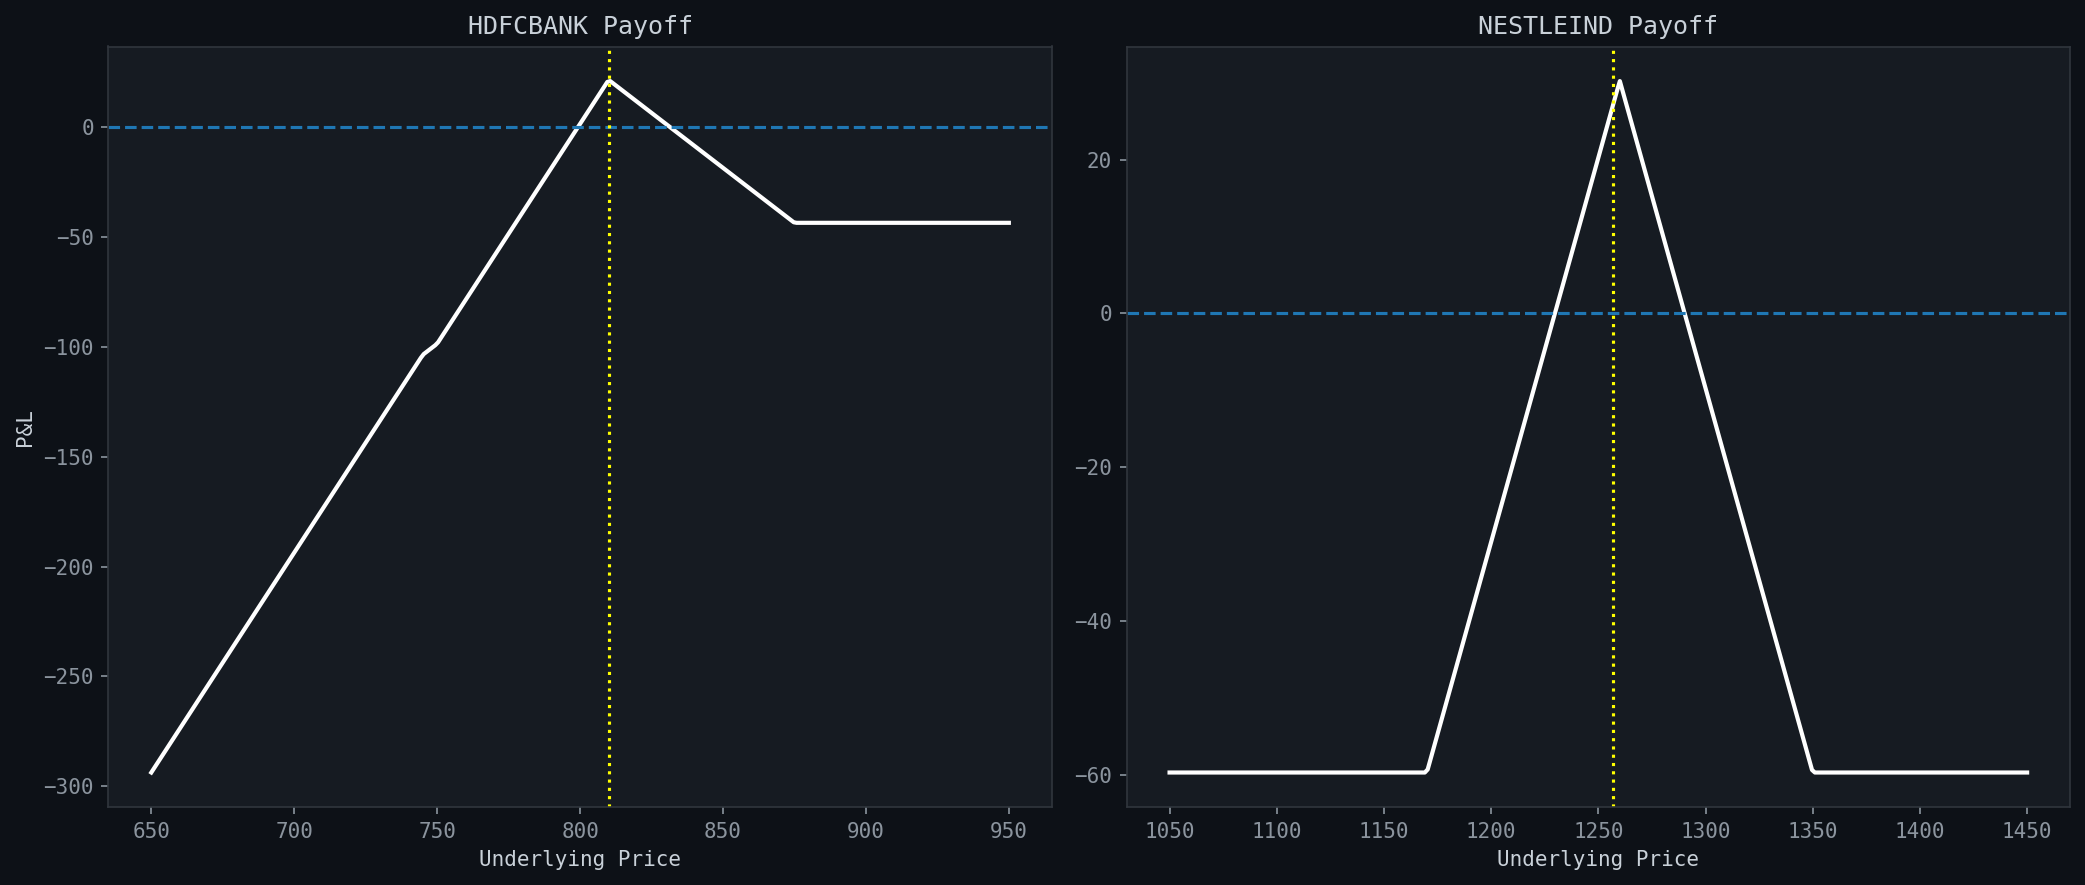

In [209]:
plt.figure(figsize=(14,6))

# HDFC
plt.subplot(1,2,1)
plt.plot(S1, p1, color='white', linewidth=2)
plt.axhline(0, linestyle='--')
plt.axvline(S_hdfc, linestyle=':', color='yellow')
plt.title("HDFCBANK Payoff")
plt.xlabel("Underlying Price")
plt.ylabel("P&L")

# Nestle
plt.subplot(1,2,2)
plt.plot(S2, p2, color='white', linewidth=2)
plt.axhline(0, linestyle='--')
plt.axvline(S_nestle, linestyle=':', color='yellow')
plt.title("NESTLEIND Payoff")
plt.xlabel("Underlying Price")

plt.tight_layout()
plt.show()

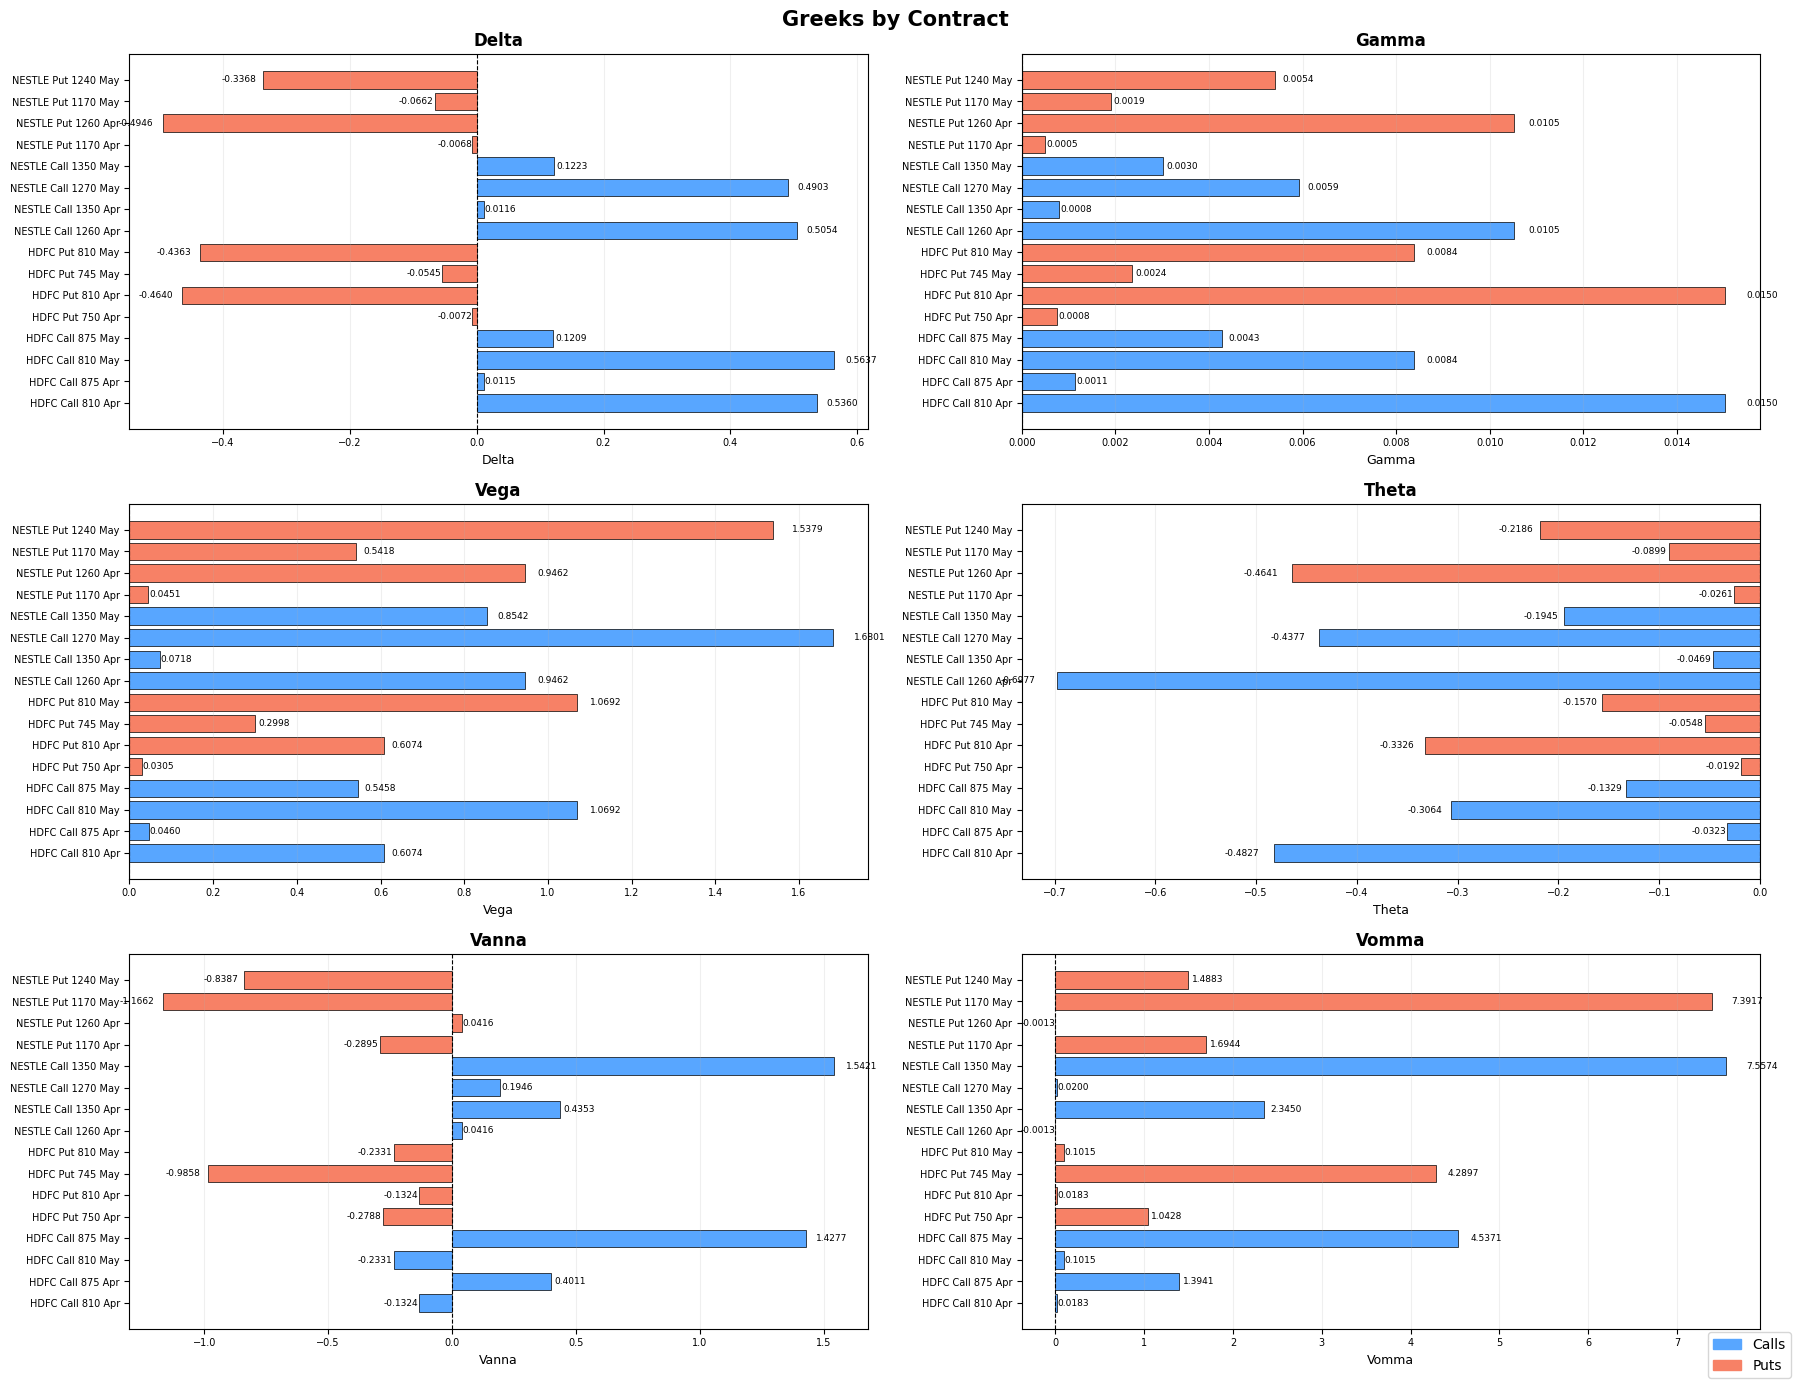

In [ ]:
44